# ============================================================
# STOCK PRICE PREDICTION USING RNN, GRU, AND DEEP LSTM
# Dataset: ADANIPORTS.csv
# ============================================================

# ======================
# IMPORT LIBRARIES
# ======================


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, LSTM, Dropout

### LOAD DATASET

In [37]:
df = pd.read_csv("/content/ADANIPORTS.csv")

print(df.head())


         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN              816123   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  
3       0.2735  
4

### DATA PREPROCESSING

In [38]:
# Convert Date column into datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Keep only Date and Close price
data = df[['Date', 'Close']]

print(data.head())

        Date   Close
0 2007-11-27  962.90
1 2007-11-28  893.90
2 2007-11-29  884.20
3 2007-11-30  921.55
4 2007-12-03  969.30


### VISUALIZE STOCK PRICE

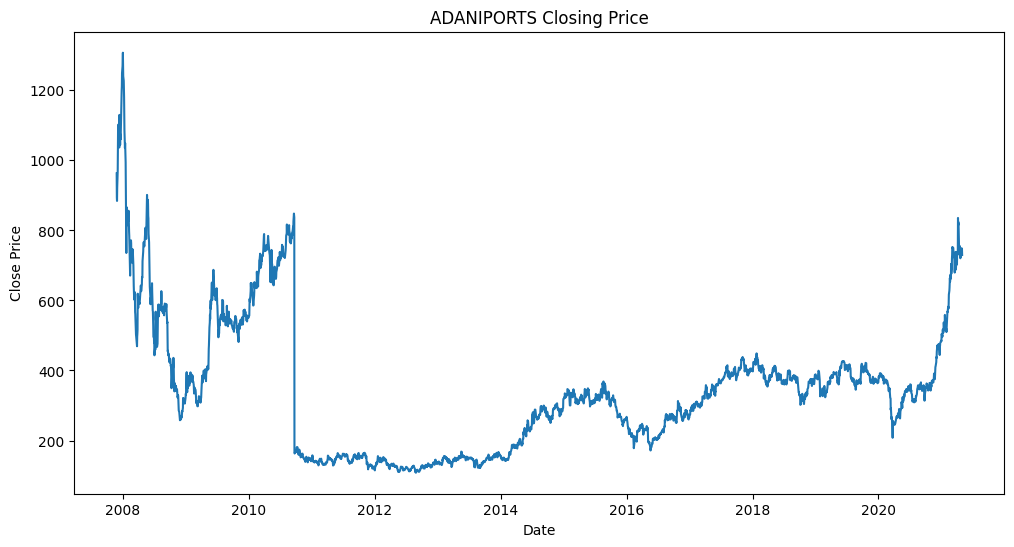

In [39]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'])
plt.title("ADANIPORTS Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()


### NORMALIZATION

In [40]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data[['Close']])


## CREATE SEQUENCES

In [41]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for Deep Learning Models
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X Shape :", X.shape)
print("y Shape :", y.shape)


X Shape : (3262, 60, 1)
y Shape : (3262,)


## TRAIN TEST SPLIT

In [42]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# SIMPLE RNN MODEL

In [43]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(64, return_sequences=True,
                        input_shape=(X_train.shape[1],1)))

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(64))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam',
                  loss='mean_squared_error')

print(rnn_model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

None


### Train Model

In [44]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0451 - val_loss: 6.5880e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0082 - val_loss: 2.7690e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0045 - val_loss: 2.5853e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0035 - val_loss: 2.2234e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031 - val_loss: 1.4516e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0025 - val_loss: 1.7640e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020 - val_loss: 2.2376e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0020 - val_loss: 1.8783e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017 - val_loss: 1.1786e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0015 - val_loss: 2.4944e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 9.8011e-05
Epoch 12/20
82/82 ━

# GRU MODEL

In [45]:
gru_model = Sequential()

gru_model.add(GRU(64, return_sequences=True,
                  input_shape=(X_train.shape[1],1)))

gru_model.add(Dropout(0.2))

gru_model.add(GRU(64))

gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

gru_model.compile(optimizer='adam',
                  loss='mean_squared_error')

print(gru_model.summary())


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

None


# Train Model

In [46]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0040 - val_loss: 3.1957e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 9.4554e-04 - val_loss: 2.8390e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 8.1927e-04 - val_loss: 1.6163e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 7.6864e-04 - val_loss: 2.2910e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 7.8499e-04 - val_loss: 1.7783e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 6.8120e-04 - val_loss: 1.3957e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 6.4680e-04 - val_loss: 3.0438e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 5.6983e-04 - val_loss: 1.5021e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 5.7174e-04 - val_loss: 1.3214e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 5.5511e-04 - val_loss: 1.4877e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 5.5405e-04 - 

### DEEP LSTM MODEL

In [47]:
deep_lstm_model = Sequential()

deep_lstm_model.add(LSTM(128,
                         return_sequences=True,
                         input_shape=(X_train.shape[1],1)))

deep_lstm_model.add(Dropout(0.3))

deep_lstm_model.add(LSTM(128,
                         return_sequences=True))

deep_lstm_model.add(Dropout(0.3))

deep_lstm_model.add(LSTM(64))

deep_lstm_model.add(Dropout(0.3))

deep_lstm_model.add(Dense(1))

deep_lstm_model.compile(optimizer='adam',
                        loss='mean_squared_error')

print(deep_lstm_model.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,617 (967.25 KB)

 Trainable params: 247,617 (967.25 KB)

 Non-trainable params: 0 (0.00 B)

None


# Train Model

In [48]:
lstm_history = deep_lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - loss: 0.0036 - val_loss: 5.1509e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - loss: 0.0015 - val_loss: 6.6124e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 0.0013 - val_loss: 7.2393e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - loss: 0.0013 - val_loss: 3.5004e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 0.0014 - val_loss: 2.6655e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - loss: 0.0012 - val_loss: 2.6676e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 0.0010 - val_loss: 4.4924e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - loss: 9.8112e-04 - val_loss: 5.2163e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - loss: 9.8261e-04 - val_loss: 2.3102e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - loss: 9.3634e-04 - val_loss: 

### PREDICTIONS

In [49]:
nn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = deep_lstm_model.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


# INVERSE TRANSFORM

In [50]:
nn_pred = scaler.inverse_transform(nn_pred)
gru_pred = scaler.inverse_transform(gru_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# EVALUATION

In [55]:
rnn_mae = mean_absolute_error(y_test_actual, nn_pred)
gru_mae = mean_absolute_error(y_test_actual, gru_pred)
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

print("\n===== MODEL PERFORMANCE =====")

print(f"RNN MAE        : {rnn_mae:.4f}")
print(f"GRU MAE        : {gru_mae:.4f}")
print(f"Deep LSTM MAE  : {lstm_mae:.4f}")


===== MODEL PERFORMANCE =====
RNN MAE        : 9.9162
GRU MAE        : 10.2767
Deep LSTM MAE  : 13.8750


# RMSE

In [56]:
mae_scores = {
    "RNN": rnn_mae,
    "GRU": gru_mae,
    "Deep LSTM": lstm_mae
}

best_model = min(mae_scores, key=mae_scores.get)

print("\nBest Performing Model :", best_model)




Best Performing Model : RNN


 VISUALIZATION

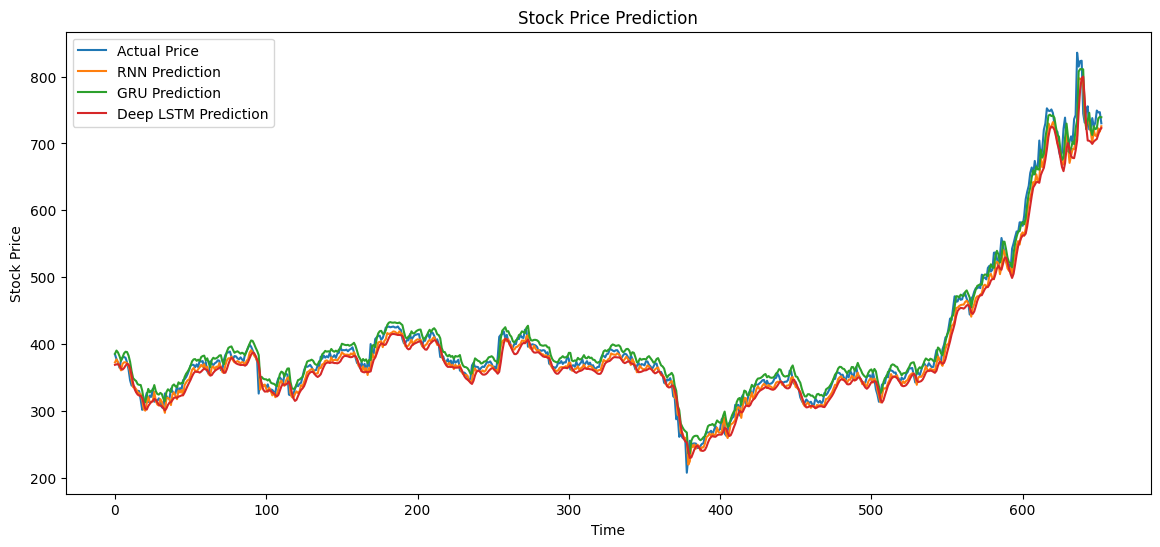

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to array
y_test_actual = np.array(y_test_actual)

# Flatten arrays
y_test_actual = y_test_actual.flatten()
nn_pred = nn_pred.flatten()
gru_pred = gru_pred.flatten()
lstm_pred = lstm_pred.flatten()

plt.figure(figsize=(14,6))

plt.plot(y_test_actual,
         label='Actual Price')

plt.plot(nn_pred,
         label='RNN Prediction')

plt.plot(gru_pred,
         label='GRU Prediction')

plt.plot(lstm_pred,
         label='Deep LSTM Prediction')

plt.title('Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()